## Import Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.pyplot import get_cmap
# Load HMF v3_iter3 data (with mass cut 1e11)
import os
from pathlib import Path
import pandas as pd
import numpy as np
from galform_analysis.config import get_base_dir, get_snapshot_redshift
from galform_analysis.analysis import (
    completed_galaxies,
    avg_hmf_given_redshift_and_subvolumes,
    avg_correlation_given_redshift_and_subvolumes,
)
from galform_analysis.analysis.correlation.correlation import avg_correlation_given_redshift_and_subvolumes

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

project_root = Path.cwd()
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

base_dir = Path(get_base_dir())

## HMF CONVERGENCE PLOTS: Compare n_ivols to 1024 referenc

Loaded HMF iz271: z = 0.000
Loaded HMF iz207: z = 0.496


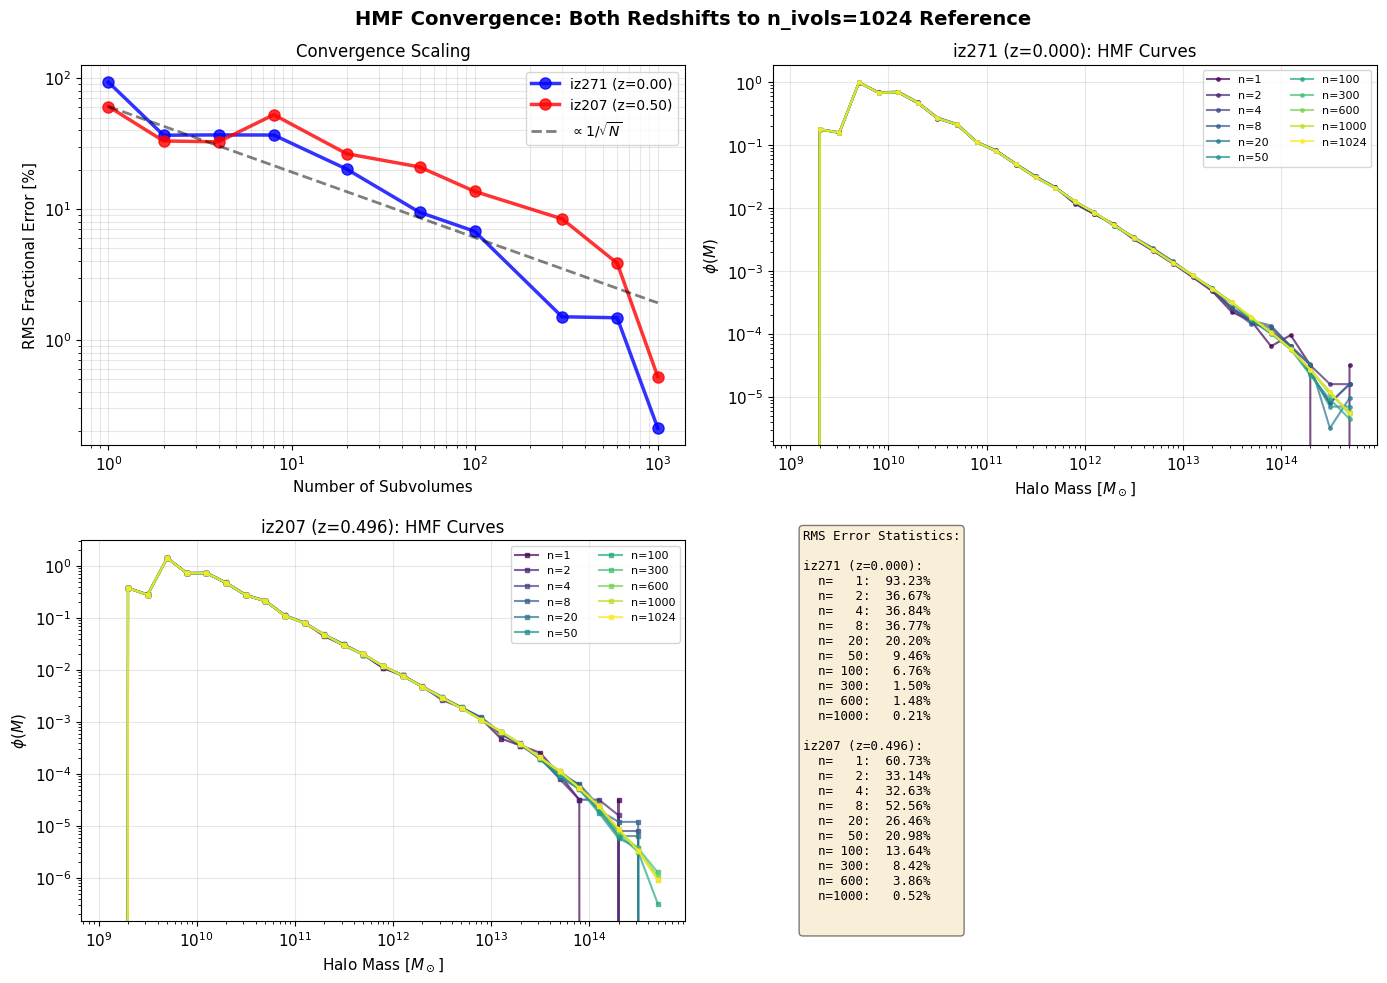

In [2]:
# Load the corrected HMF data for BOTH redshifts
import os
workspace_root = Path('/cosma/home/durham/dc-hick2/galform_analysis')
hmf_iz271 = pd.read_csv(workspace_root / 'convergence_results' / 'hmf_convergence_iz271.csv')
hmf_iz207 = pd.read_csv(workspace_root / 'convergence_results' / 'hmf_convergence_iz207.csv')

print(f"Loaded HMF iz271: z = {hmf_iz271['z'].iloc[0]:.3f}")
print(f"Loaded HMF iz207: z = {hmf_iz207['z'].iloc[0]:.3f}")

# Create convergence plots with both redshifts overlaid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HMF Convergence: Both Redshifts to n_ivols=1024 Reference', fontsize=14, fontweight='bold')

redshift_data = [(hmf_iz271, 'iz271', 'blue'), (hmf_iz207, 'iz207', 'red')]

# Subplot 1: Convergence metric (both redshifts overlaid)
ax = axes[0, 0]
for hmf_data, iz_label, color in redshift_data:
    hmf_ref = hmf_data[hmf_data['n_ivols'] == 1024].sort_values('log_Mhalo')
    n_ivols_list = sorted(hmf_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
        ref_phi = hmf_ref['phi'].values
        hmf_phi = hmf_subset['phi'].values
        valid = (ref_phi > 0) & np.isfinite(ref_phi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((hmf_phi[valid] - ref_phi[valid]) / ref_phi[valid])**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    ax.loglog(conv_df['n_ivols'], conv_df['rms_diff'], marker='o', markersize=8, 
              color=color, linewidth=2.5, label=f'{iz_label} (z={hmf_data["z"].iloc[0]:.2f})', alpha=0.8)

n_ref_plot = conv_df['n_ivols'].values
rms_ref_plot = conv_df['rms_diff'].iloc[0]
ax.loglog(n_ref_plot, rms_ref_plot * np.sqrt(n_ref_plot[0] / n_ref_plot), 'k--', linewidth=2, 
          label=r'$\propto 1/\sqrt{N}$', alpha=0.5)
ax.set_xlabel('Number of Subvolumes', fontsize=11)
ax.set_ylabel('RMS Fractional Error [%]', fontsize=11)
ax.set_title('Convergence Scaling', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 2: HMF curves (iz271)
ax = axes[0, 1]
hmf_data = hmf_iz271
n_ivols_list = sorted(hmf_data['n_ivols'].unique())
colors_n = plt.cm.viridis(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
    ax.loglog(10**hmf_subset['log_Mhalo'], hmf_subset['phi'], marker='o', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Halo Mass [$M_\odot$]', fontsize=11)
ax.set_ylabel('$\phi(M)$', fontsize=11)
ax.set_title(f'iz271 (z={hmf_iz271["z"].iloc[0]:.3f}): HMF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# Subplot 3: HMF curves (iz207)
ax = axes[1, 0]
hmf_data = hmf_iz207
n_ivols_list = sorted(hmf_data['n_ivols'].unique())
colors_n = plt.cm.viridis(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
    ax.loglog(10**hmf_subset['log_Mhalo'], hmf_subset['phi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Halo Mass [$M_\odot$]', fontsize=11)
ax.set_ylabel('$\phi(M)$', fontsize=11)
ax.set_title(f'iz207 (z={hmf_iz207["z"].iloc[0]:.3f}): HMF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

# Subplot 4: Statistics table
ax = axes[1, 1]
ax.axis('off')
stats_text = "RMS Error Statistics:\n\n"
for hmf_data, iz_label, _ in redshift_data:
    hmf_ref = hmf_data[hmf_data['n_ivols'] == 1024].sort_values('log_Mhalo')
    n_ivols_list = sorted(hmf_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        hmf_subset = hmf_data[hmf_data['n_ivols'] == n_ivol].sort_values('log_Mhalo')
        ref_phi = hmf_ref['phi'].values
        hmf_phi = hmf_subset['phi'].values
        valid = (ref_phi > 0) & np.isfinite(ref_phi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((hmf_phi[valid] - ref_phi[valid]) / ref_phi[valid])**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    stats_text += f"{iz_label} (z={hmf_data['z'].iloc[0]:.3f}):\n"
    for idx, row in conv_df.iterrows():
        stats_text += f"  n={int(row['n_ivols']):4d}: {row['rms_diff']:6.2f}%\n"
    stats_text += "\n"
ax.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 2PCF CONVERGENCE PLOTS: Compare n_ivols to 1024 referenc


Loaded 2PCF iz271: z = 0.000
Loaded 2PCF iz207: z = 0.496


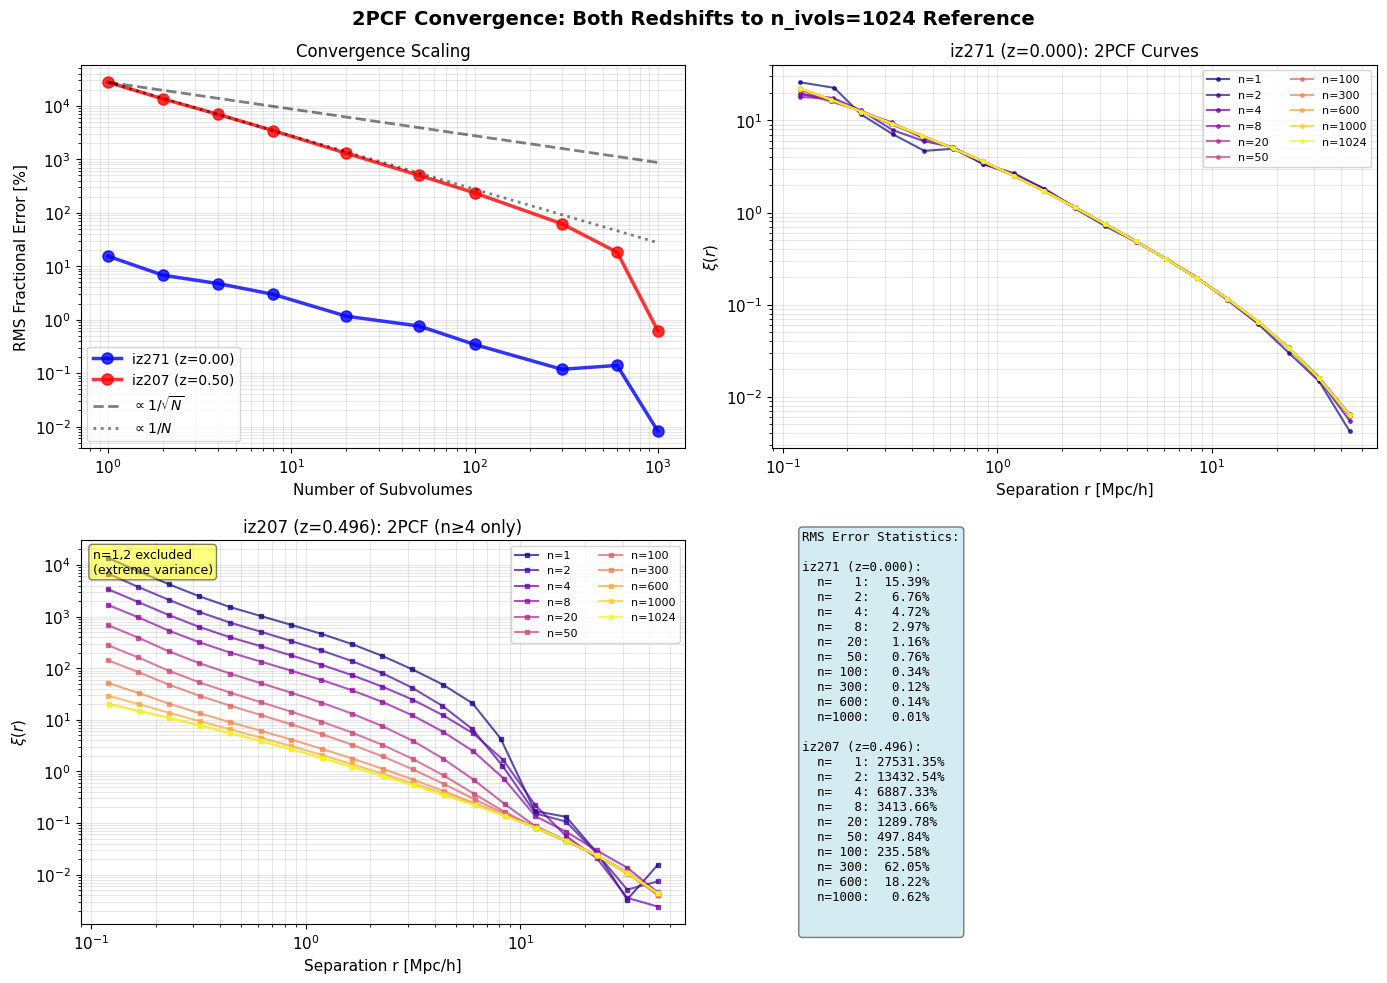

In [5]:
# Load the corrected 2PCF data for BOTH redshifts
corr_iz271 = pd.read_csv(workspace_root / 'convergence_results' / 'corr_convergence_iz271.csv')
corr_iz207 = pd.read_csv(workspace_root / 'convergence_results' / 'corr_convergence_iz207.csv')

print(f"\nLoaded 2PCF iz271: z = {corr_iz271['z'].iloc[0]:.3f}")
print(f"Loaded 2PCF iz207: z = {corr_iz207['z'].iloc[0]:.3f}")

# Create convergence plots with both redshifts overlaid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('2PCF Convergence: Both Redshifts to n_ivols=1024 Reference', fontsize=14, fontweight='bold')

redshift_data_corr = [(corr_iz271, 'iz271', 'blue'), (corr_iz207, 'iz207', 'red')]

# Subplot 1: Convergence metric (both redshifts overlaid)
ax = axes[0, 0]
for corr_data, iz_label, color in redshift_data_corr:
    corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
    n_ivols_list = sorted(corr_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
        ref_xi = corr_ref['xi'].values
        corr_xi = corr_subset['xi'].values
        valid = (ref_xi != 0) & np.isfinite(ref_xi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    ax.loglog(conv_df['n_ivols'], conv_df['rms_diff'], marker='o', markersize=8, 
              color=color, linewidth=2.5, label=f'{iz_label} (z={corr_data["z"].iloc[0]:.2f})', alpha=0.8)

n_ref_plot = conv_df['n_ivols'].values
rms_ref_plot = conv_df['rms_diff'].iloc[0]
ax.loglog(n_ref_plot, rms_ref_plot * np.sqrt(n_ref_plot[0] / n_ref_plot), 'k--', linewidth=2, 
          label=r'$\propto 1/\sqrt{N}$', alpha=0.5)
ax.loglog(n_ref_plot, rms_ref_plot * n_ref_plot[0] / n_ref_plot, 'k:', linewidth=2, 
          label=r'$\propto 1/N$', alpha=0.5)
ax.set_xlabel('Number of Subvolumes', fontsize=11)
ax.set_ylabel('RMS Fractional Error [%]', fontsize=11)
ax.set_title('Convergence Scaling', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 2: 2PCF curves (iz271)
ax = axes[0, 1]
corr_data = corr_iz271
n_ivols_list = sorted(corr_data['n_ivols'].unique())
colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_list)))
color_dict = {n: c for n, c in zip(n_ivols_list, colors_n)}
for n_ivol in n_ivols_list:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='o', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz271 (z={corr_iz271["z"].iloc[0]:.3f}): 2PCF Curves', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Subplot 3: 2PCF curves (iz207) -
ax = axes[1, 0]
corr_data = corr_iz207
n_ivols_list = sorted(corr_data['n_ivols'].unique())

# maybe out n=1,2 for iz207 due 
n_ivols_filtered = [n for n in n_ivols_list]# if n >= 4]

colors_n = plt.cm.plasma(np.linspace(0, 1, len(n_ivols_filtered)))
color_dict = {n: c for n, c in zip(n_ivols_filtered, colors_n)}
for n_ivol in n_ivols_filtered:
    corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
    valid_idx = corr_subset['xi'] > 0
    ax.loglog(corr_subset[valid_idx]['r'], corr_subset[valid_idx]['xi'], marker='s', markersize=2.5, 
              label=f'n={n_ivol}', color=color_dict[n_ivol], alpha=0.7, linewidth=1.5)
ax.set_xlabel('Separation r [Mpc/h]', fontsize=11)
ax.set_ylabel('$\\xi(r)$', fontsize=11)
ax.set_title(f'iz207 (z={corr_iz207["z"].iloc[0]:.3f}): 2PCF (n≥4 only)', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(True, alpha=0.3, which='both')
ax.text(0.02, 0.98, 'n=1,2 excluded\n(extreme variance)', 
        transform=ax.transAxes, fontsize=9, va='top', 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Subplot 4: Statistics table
ax = axes[1, 1]
ax.axis('off')
stats_text = "RMS Error Statistics:\n\n"
for corr_data, iz_label, _ in redshift_data_corr:
    corr_ref = corr_data[corr_data['n_ivols'] == 1024].sort_values('r')
    n_ivols_list = sorted(corr_data['n_ivols'].unique())
    convergence_metric = []
    for n_ivol in n_ivols_list[:-1]:
        corr_subset = corr_data[corr_data['n_ivols'] == n_ivol].sort_values('r')
        ref_xi = corr_ref['xi'].values
        corr_xi = corr_subset['xi'].values
        valid = (ref_xi != 0) & np.isfinite(ref_xi)
        if valid.sum() > 0:
            rms_diff = np.sqrt(np.mean(((corr_xi[valid] - ref_xi[valid]) / np.abs(ref_xi[valid]))**2)) * 100
        else:
            rms_diff = np.nan
        convergence_metric.append({'n_ivols': n_ivol, 'rms_diff': rms_diff})
    conv_df = pd.DataFrame(convergence_metric).dropna()
    stats_text += f"{iz_label} (z={corr_data['z'].iloc[0]:.3f}):\n"
    for idx, row in conv_df.iterrows():
        stats_text += f"  n={int(row['n_ivols']):4d}: {row['rms_diff']:6.2f}%\n"
    stats_text += "\n"
ax.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

## Understanding Pair Counts (DD)

In [7]:
# Extract pair counts (DD) from multiple n values
from Corrfunc.theory.xi import xi as corrfunc_xi
import pandas as pd
from galform_analysis.analysis.correlation.correlation import _load_positions_from_hdf5

pair_counts_data = []
base_dir_path = Path(get_base_dir())

for iz_num in [271, 207]:
    iz_name = f"iz{iz_num}"
    print(f"\n{iz_name}:")
    
    boxsize = 542.158
    r_target = 2.0
    for n in [1, 2, 4, 8, 20, 50, 100]:
        
        all_pos = []
        iz_path = str(base_dir_path / iz_name)
        for ivol in range(n):
            try:
                pos, _ = _load_positions_from_hdf5(iz_path, ivol, centrals_only=True)
                all_pos.append(pos)
            except (FileNotFoundError, KeyError):
                print("fail")
        
        if not all_pos:
            continue
            
        combined_pos = np.vstack(all_pos)
        ngal = len(combined_pos)
        
        
        rbins_test = np.logspace(np.log10(0.5), np.log10(20), 15)
        results = corrfunc_xi(
            boxsize=boxsize,
            nthreads=4,
            binfile=rbins_test,
            X=combined_pos[:, 0],
            Y=combined_pos[:, 1],
            Z=combined_pos[:, 2],
            output_ravg=True,
        )
        
        dd = None
        for res in results:
            if res['ravg'] >= r_target:
                dd = int(res['npairs'])
                break
        
        if dd is not None:
            pair_counts_data.append({
                'iz': iz_name,
                'n': n,
                'ngal': ngal,
                'dd_actual': dd,
            })
            
            print(f"  n={n:3d}: N_gal={ngal:10d}, DD(r={r_target})={dd:10d}")

pair_counts_df = pd.DataFrame(pair_counts_data)
print("\n" + "="*70)
print("Pair Counts Summary:")
print(pair_counts_df)



iz271:


RuntimeError: RuntimeError occurred

In [ ]:
# Analyze how DD scales with N_gal
for iz_name in ['iz271', 'iz207']:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].copy()
    
    print(f"\n{iz_name}:")
    print(f"  {'n':>3} | {'N_gal':>10} | {'DD':>10} | {'DD/N²':>12}")
    
    # Calculate expected scaling
    ref_row = data.iloc[0]
    ref_dd_per_n2 = ref_row['dd_actual'] / (ref_row['ngal']**2)
    
    for idx, row in data.iterrows():
        dd_per_n2 = row['dd_actual'] / (row['ngal']**2)
        scaling = dd_per_n2 / ref_dd_per_n2
        print(f"  {row['n']:3d} | {row['ngal']:10d} | {row['dd_actual']:10d} | {dd_per_n2:12.4e}")


iz271:
    n |      N_gal |         DD |        DD/N²
    1 |      71289 |       2266 |   4.4588e-07
    2 |     142658 |       9314 |   4.5766e-07
    4 |     285889 |      37464 |   4.5837e-07
    8 |     573140 |     150146 |   4.5708e-07
   20 |    1431334 |     935196 |   4.5648e-07
   50 |    3575764 |    5858180 |   4.5817e-07
  100 |    7152230 |   23445490 |   4.5833e-07

iz207:
    n |      N_gal |         DD |        DD/N²
    1 |      96316 |     366580 |   3.9516e-05
    2 |     193007 |     691530 |   1.8564e-05
    4 |     389471 |    1541202 |   1.0160e-05
    8 |     780984 |    3201218 |   5.2484e-06
   20 |    1935946 |    7238388 |   1.9313e-06
   50 |    4834528 |   22221126 |   9.5073e-07
  100 |    9664269 |   60468744 |   6.4743e-07


## DD vs n and DD/N^2 vs n for both redshifts

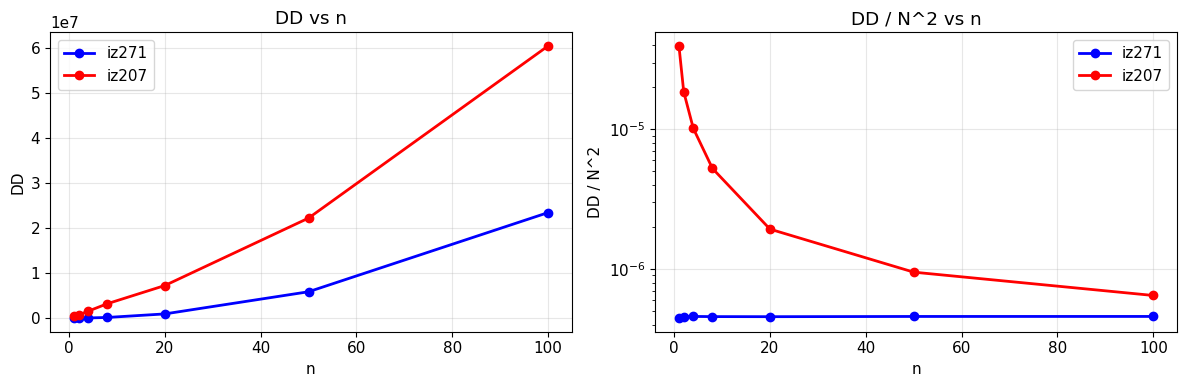

In [ ]:
# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for iz_name, color in [('iz271', 'blue'), ('iz207', 'red')]:
    data = pair_counts_df[pair_counts_df['iz'] == iz_name].sort_values('n')
    if data.empty:
        continue
    n_vals = data['n'].values
    dd_vals = data['dd_actual'].values
    dd_per_n2_vals = dd_vals / (data['ngal'].values ** 2)

    axes[0].plot(n_vals, dd_vals, marker='o', linewidth=2, color=color, label=iz_name)
    axes[1].plot(n_vals, dd_per_n2_vals, marker='o', linewidth=2, color=color, label=iz_name)

axes[0].set_xlabel('n')
axes[0].set_ylabel('DD')
axes[0].set_title('DD vs n')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('n')
axes[1].set_ylabel('DD / N^2')
axes[1].set_title('DD / N^2 vs n')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()